# Detecção de Fraudes em Transações em Cartões de Crédito

### 1. Carregar dataset

In [1]:
import pandas as pd
import logging

logging.basicConfig(level=logging.INFO)

logging.info("Carregando o arquivo CSV...")

url = r"C:/Users/vitor/.local/Arquivos_Jupiter/creditcard.csv"
df = pd.read_csv(url)

logging.info("Arquivo CSV carregado com sucesso.")

logging.info("Primeiras linhas do DataFrame:")
df.head()

INFO:root:Carregando o arquivo CSV...
INFO:root:Arquivo CSV carregado com sucesso.
INFO:root:Primeiras linhas do DataFrame:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### 2. Classificação desbalanceada

In [2]:
logging.info("Distribuição das Classes:")

df["Class"].value_counts(normalize=True)

INFO:root:Distribuição das Classes:


Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

### 3. Features engineering e temporais

Coluna para hora do dia:

In [3]:
logging.info("Convertendo Time para hora do dia...")

df["Hour"] = (df["Time"] // 3600) % 24

logging.info("Converção concluída.")

INFO:root:Convertendo Time para hora do dia...
INFO:root:Converção concluída.


Coluna para as 4 faixas de tempo (magrugada, manhã, tarde, noite), cada uma descrita em um código:

In [4]:
def time_period(h):
    madrugada = 1.0
    manhã = 2.0
    tarde = 3.0
    noite = 4.0
    
    if 0 <= h < 6:
        return madrugada
    elif 6 <= h < 12:
        return manhã
    elif 12 <= h < 18:
        return tarde
    else:
        return noite

logging.info("Criando faixas de tempo...")
df["time_period"] = df["Hour"].apply(time_period)
logging.info("Faixas de tempo criadas com sucesso.")

INFO:root:Criando faixas de tempo...
INFO:root:Faixas de tempo criadas com sucesso.


Coluna para a frequência de transações a cada 15 minutos de tempo:

In [5]:
import numpy as np

logging.info("Iniciando a criação da frequência de transações por janela de tempo...")
df = df.sort_values('Time')
times = df['Time'].values

logging.info("Criando a janela de 15 minutos...")
window = 15 * 60
counts = []

logging.info("Definindo o número de transações nos últimos 15 minutos...")
for i in range(len(times)):
    t = times[i]
    start = t - window
    j = np.searchsorted(times, start, side='left')
    counts.append(i - j)

df["transacoes_15min"] = counts
logging.info("Frequência de transações por janela de tempo criada com sucesso.")

INFO:root:Iniciando a criação da frequência de transações por janela de tempo...
INFO:root:Criando a janela de 15 minutos...
INFO:root:Definindo o número de transações nos últimos 15 minutos...
INFO:root:Frequência de transações por janela de tempo criada com sucesso.


Aplicando transformações logarítmicas e ciclos temporais:

In [6]:
logging.info("Transformando hora em seno/cosseno")
df["Hour_sin"] = np.sin(2 * np.pi * df["Hour"]/24)
df["Hour_cos"] = np.cos(2 * np.pi * df["Hour"]/24)

logging.info("Aplicando transformação logarítmica...")
df["Time_log"] = np.log1p(df["Time"])
df["Amount_log"] = np.log1p(df["Amount"])

logging.info("Transformações concluídas.")

INFO:root:Transformando hora em seno/cosseno
INFO:root:Aplicando transformação logarítmica...
INFO:root:Transformações concluídas.


In [7]:
from sklearn.preprocessing import StandardScaler

logging.info("Iniciando processo de escalonamento...")

scaler = StandardScaler()

logging.info("Escalonando as colunas 'Time' e 'Amount'...")

df["Time_scaled"] = scaler.fit_transform(df[["Time"]])
df["Amount_scaled"] = scaler.fit_transform(df[["Amount"]])

logging.info("Escalonamento concluído.")

INFO:root:Iniciando processo de escalonamento...
INFO:root:Escalonando as colunas 'Time' e 'Amount'...
INFO:root:Escalonamento concluído.


### 4. Validação de dados

In [8]:
def validar_dataset(df):
    print("Linhas:", df.shape[0])
    print("Colunas:", df.shape[1])
    print("\nValores ausentes:")
    print(df.isnull().sum())


validar_dataset(df)

Linhas: 284807
Colunas: 40

Valores ausentes:
Time                0
V1                  0
V2                  0
V3                  0
V4                  0
V5                  0
V6                  0
V7                  0
V8                  0
V9                  0
V10                 0
V11                 0
V12                 0
V13                 0
V14                 0
V15                 0
V16                 0
V17                 0
V18                 0
V19                 0
V20                 0
V21                 0
V22                 0
V23                 0
V24                 0
V25                 0
V26                 0
V27                 0
V28                 0
Amount              0
Class               0
Hour                0
time_period         0
transacoes_15min    0
Hour_sin            0
Hour_cos            0
Time_log            0
Amount_log          0
Time_scaled         0
Amount_scaled       0
dtype: int64


### 5. Divisão entre treino e teste

In [9]:
from sklearn.model_selection import train_test_split

df.dropna()
x = df.drop("Class", axis=1)
y = df["Class"]

logging.info("Dividindo os dados em conjuntos de treino e teste...")

x_train, x_test, y_train, y_test = train_test_split(
    x, y, stratify=y, test_size=0.3, random_state=42
)

logging.info("Divisão dos dados concluída.")

INFO:root:Dividindo os dados em conjuntos de treino e teste...
INFO:root:Divisão dos dados concluída.


### 6. Regressão logística

In [10]:
from sklearn.linear_model import LogisticRegression

logging.info("Iniciando o treinamento do modelo de Regressão Logística...")
model = LogisticRegression(max_iter=10000)

logging.info("Treinando o modelo...")
model.fit(x_train, y_train)

logging.info("Realizando previsões no conjunto de teste...")
y_pred = model.predict(x_test)
logging.info("Previsões concluídas.")

INFO:root:Iniciando o treinamento do modelo de Regressão Logística...
INFO:root:Treinando o modelo...
INFO:root:Realizando previsões no conjunto de teste...
INFO:root:Previsões concluídas.


In [11]:
from sklearn.metrics import classification_report

logging.info("Gerando o relatório de classificação...")
print(classification_report(y_test, y_pred))

INFO:root:Gerando o relatório de classificação...


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.88      0.63      0.73       148

    accuracy                           1.00     85443
   macro avg       0.94      0.81      0.87     85443
weighted avg       1.00      1.00      1.00     85443



Dashboard de gráficos: PR Curve e ROC Curve

In [12]:
from sklearn.metrics import roc_curve, precision_recall_curve, roc_auc_score, average_precision_score
import matplotlib.pyplot as plt

logging.info("Calculando as probabilidades de previsão para a curva ROC...")
y_probs = model.predict_proba(x_test)[:,1]

logging.info("Calculando a curva ROC...")
fpr, tpr, roc_thresholds = roc_curve(y_test, y_probs)

logging.info("Calculando a curva de Precisão-Recall...")
precision, recall, pre_thresholds = precision_recall_curve(y_test, y_probs)

logging.info("Calculos concluídos.")

INFO:root:Calculando as probabilidades de previsão para a curva ROC...
INFO:root:Calculando a curva ROC...
INFO:root:Calculando a curva de Precisão-Recall...
INFO:root:Calculos concluídos.


INFO:root:Plotando a curva de Precisio-Recall...
INFO:root:Plotando a curva ROC...


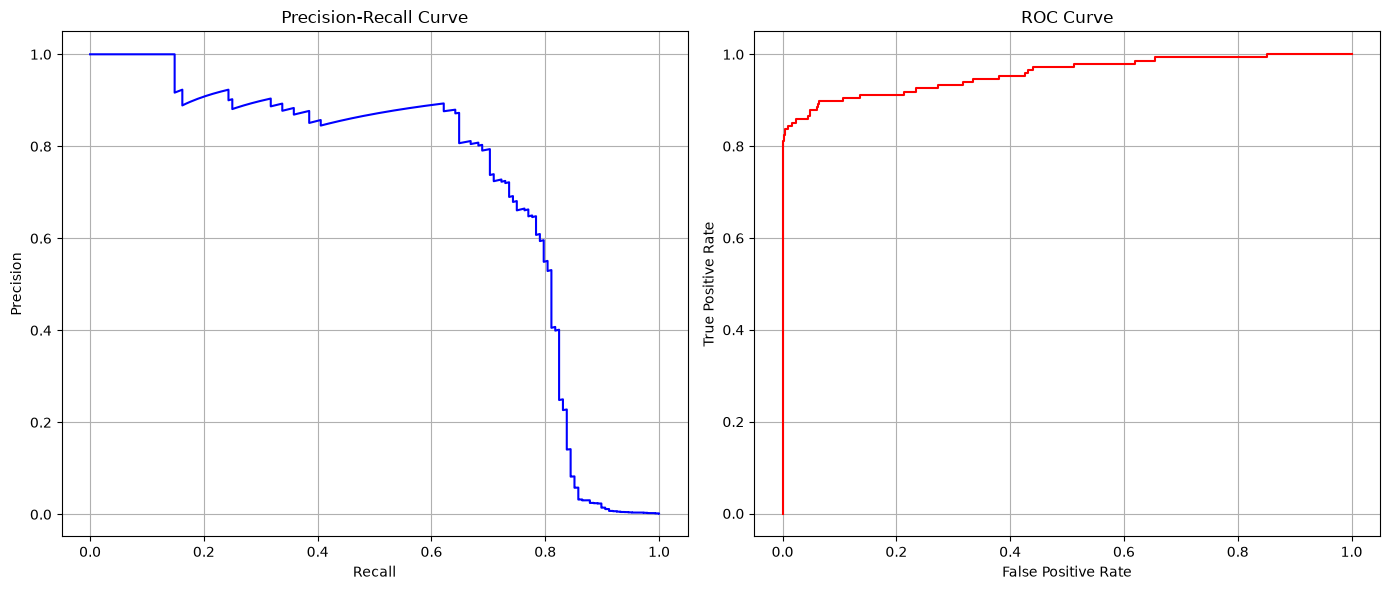

INFO:root:Curva ROC e de Precision-Recall plotadas com sucesso.
INFO:root:Calculando as áreas sob as curvas...


Roc_auc: 0.9571327966691119
Average_precision: 0.717972035385431


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Precision-recall
logging.info("Plotando a curva de Precisio-Recall...")
axes[0].plot(recall, precision, color='blue')
axes[0].set_title("Precision-Recall Curve")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].grid(True)

# ROC Curve
logging.info("Plotando a curva ROC...")
axes[1].plot(fpr, tpr, color='red')
axes[1].set_title("ROC Curve")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].grid(True)

fig.tight_layout()
plt.show()
logging.info("Curva ROC e de Precision-Recall plotadas com sucesso.")

logging.info("Calculando as áreas sob as curvas...")
print("Roc_auc:", roc_auc_score(y_test, y_probs))
print("Average_precision:", average_precision_score(y_test, y_probs))

### 7. Balanceamento de dados (SMOTE)

In [14]:
# Oversampling
from imblearn.over_sampling import SMOTE

logging.info("Iniciando o oversampling com SMOTE...")
smote = SMOTE(sampling_strategy=0.1, random_state=42)

logging.info("Aplicando SMOTE para balancear o conjunto de treino...")
x_train_res, y_train_res = smote.fit_resample(x_train, y_train)

logging.info("Oversampling concluído com sucesso.")

INFO:root:Iniciando o oversampling com SMOTE...
INFO:root:Aplicando SMOTE para balancear o conjunto de treino...
INFO:root:Oversampling concluído com sucesso.


### 8. LGBMClassifier

In [15]:
from lightgbm import LGBMClassifier

logging.info("Iniciando o treinamento do modelo LightGBM...")
lgbm = LGBMClassifier(
    n_estimators=300,
    max_depth=-1,
    learning_rate=0.05,
    class_weight="balanced",
    num_leaves=32
)

logging.info("Ajustando o modelo com os dados balanceados...")
lgbm.fit(x_train_res, y_train_res)

logging.info("Realizando previsões no conjunto de teste...")
y_pred_lgbm = lgbm.predict(x_test)

logging.info("Modelo treinado e previsões realizadas com sucesso.")

logging.info("Previsões com o modelo LightGBM concluídas.")
print(classification_report(y_test, y_pred_lgbm))

INFO:root:Iniciando o treinamento do modelo LightGBM...
INFO:root:Ajustando o modelo com os dados balanceados...


[LightGBM] [Info] Number of positive: 19902, number of negative: 199020
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.361642 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9945
[LightGBM] [Info] Number of data points in the train set: 218922, number of used features: 39
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


INFO:root:Realizando previsões no conjunto de teste...
INFO:root:Modelo treinado e previsões realizadas com sucesso.
INFO:root:Previsões com o modelo LightGBM concluídas.


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.83      0.82      0.83       148

    accuracy                           1.00     85443
   macro avg       0.92      0.91      0.91     85443
weighted avg       1.00      1.00      1.00     85443



Ajuste de threshold:

In [16]:
logging.info("Definindo o threshold para previsão...")
threshold = 0.26

logging.info(f"Calculando as probabilidades de previsão com o modelo LightGBM...")
y_probs_lgbm = lgbm.predict_proba(x_test)[:, 1]

logging.info(f"Aplicando o threshold de {threshold} para gerar previsões binárias...")
y_pred_final = (y_probs_lgbm > threshold).astype(int)

logging.info("Gerando o relatório de classificação com o threshold customizado...")
print(classification_report(y_test, y_pred_final))

INFO:root:Definindo o threshold para previsão...
INFO:root:Calculando as probabilidades de previsão com o modelo LightGBM...
INFO:root:Aplicando o threshold de 0.26 para gerar previsões binárias...
INFO:root:Gerando o relatório de classificação com o threshold customizado...


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.78      0.84      0.81       148

    accuracy                           1.00     85443
   macro avg       0.89      0.92      0.90     85443
weighted avg       1.00      1.00      1.00     85443



Dashboard de gráficos: PR Curve e ROC Curve

In [17]:
logging.info("Calculando as probabilidades de previsão para a curva ROC...")
y_probs_lgbm = lgbm.predict_proba(x_test)[:,1]

logging.info("Calculando a curva ROC...")
fpr, tpr, roc_thresholds = roc_curve(y_test, y_probs_lgbm)

logging.info("Calculando a curva de Precisão-Recall...")
precision, recall, pre_thresholds = precision_recall_curve(y_test, y_probs_lgbm)

logging.info("Calculos concluídos.")

INFO:root:Calculando as probabilidades de previsão para a curva ROC...


INFO:root:Calculando a curva ROC...
INFO:root:Calculando a curva de Precisão-Recall...
INFO:root:Calculos concluídos.


INFO:root:Plotando a curva de Precisio-Recall...
INFO:root:Plotando a curva ROC...


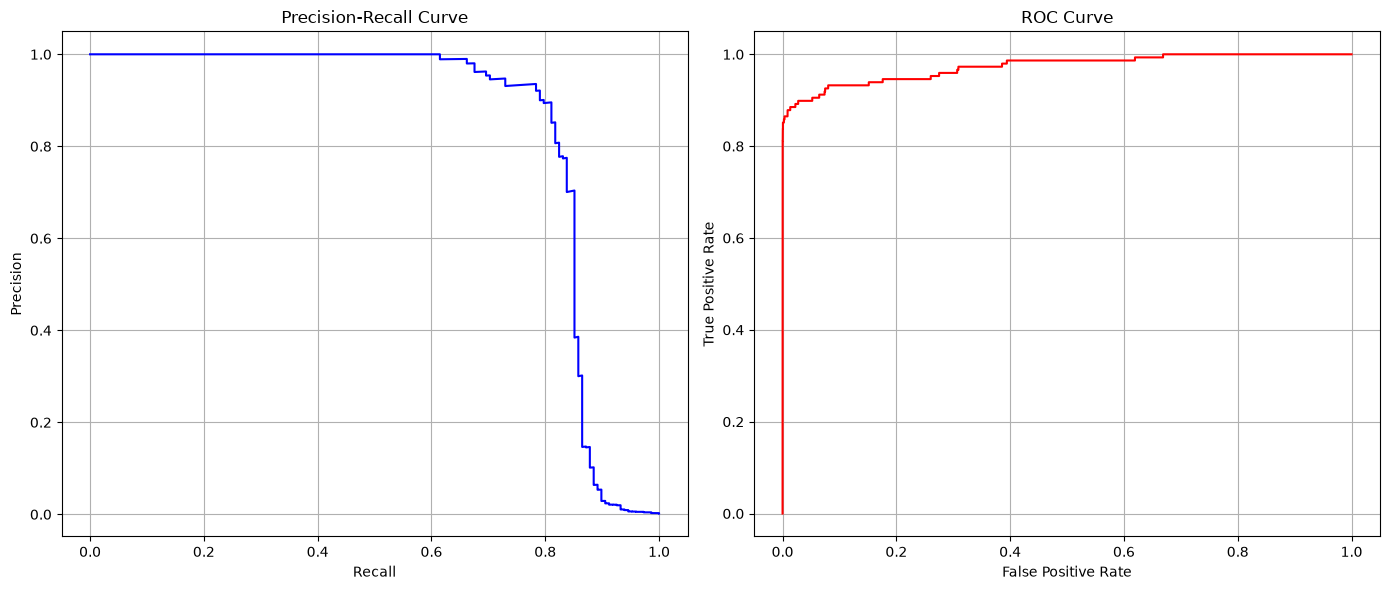

INFO:root:Curva ROC e de Precision-Recall plotadas com sucesso.
INFO:root:Calculando as áreas sob as curvas...


Roc_auc: 0.9730811032616532
Average_precision: 0.8418253608366856


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Precision-recall
logging.info("Plotando a curva de Precisio-Recall...")
axes[0].plot(recall, precision, color='blue')
axes[0].set_title("Precision-Recall Curve")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].grid(True)

# ROC Curve
logging.info("Plotando a curva ROC...")
axes[1].plot(fpr, tpr, color='red')
axes[1].set_title("ROC Curve")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].grid(True)

fig.tight_layout()
plt.show()
logging.info("Curva ROC e de Precision-Recall plotadas com sucesso.")

logging.info("Calculando as áreas sob as curvas...")
print("Roc_auc:", roc_auc_score(y_test, y_probs_lgbm))
print("Average_precision:", average_precision_score(y_test, y_probs_lgbm))

### 9. Matriz de confusão e impactos financeiros

INFO:root:importando bibliotecas...
INFO:root: Iniciando a criação da matriz de confusão...
INFO:root:Criando o gráfico da matriz...
INFO:root:Plotando o gráfico...


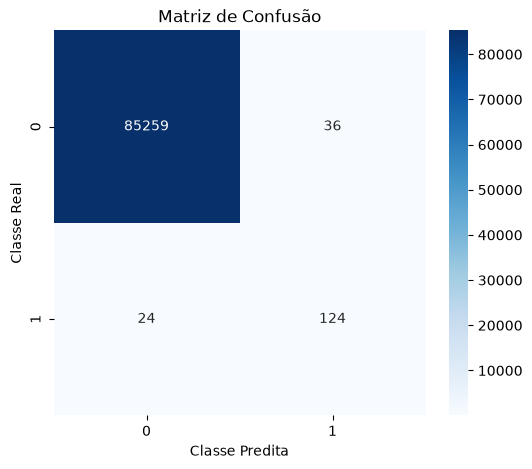

In [19]:
logging.info("importando bibliotecas...")
from sklearn.metrics import confusion_matrix
import seaborn as sns

logging.info(" Iniciando a criação da matriz de confusão...")
cm = confusion_matrix(y_test, y_pred_final)

logging.info("Criando o gráfico da matriz...")
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

logging.info("Plotando o gráfico...")
plt.xlabel("Classe Predita")
plt.ylabel("Classe Real")
plt.title("Matriz de Confusão")
plt.show()

Calculo dos Impactos financeiros:

In [20]:
TN, FP, FN, TP = cm.ravel()

logging.info("Definindo custos com a detecção...")

beneficio_fraude_detectada = 500
custo_fraude_perdida = 500
custo_falso_positivo = 10

logging.info("Calculando o valor do impacto financeiro total...")

impacto_total = (
    TP * beneficio_fraude_detectada - FN * custo_fraude_perdida - FP * custo_falso_positivo
)

logging.info("Informações da matriz e impacto financeiro total:")

print("\nFraudes detectadas:", TP)
print("Transações legítimas marcadas como fraude:", FP)
print("Fraudes perdidas:", FN)
print("Transações legítimas corretas:", TN)
print(f"\nDinheiro recuperado por fraude detectada: R$ {TP * beneficio_fraude_detectada}")
print(f"Prejuízo por fraude não detectada: R$ {FN * custo_fraude_perdida}")
print(f"Gasto com falsos positivos: R$ {FP * custo_falso_positivo}")
print(f"\nImpacto financeiro total: R$ {impacto_total} de ganho líquido.")

INFO:root:Definindo custos com a detecção...
INFO:root:Calculando o valor do impacto financeiro total...
INFO:root:Informações da matriz e impacto financeiro total:



Fraudes detectadas: 124
Transações legítimas marcadas como fraude: 36
Fraudes perdidas: 24
Transações legítimas corretas: 85259

Dinheiro recuperado por fraude detectada: R$ 62000
Prejuízo por fraude não detectada: R$ 12000
Gasto com falsos positivos: R$ 360

Impacto financeiro total: R$ 49640 de ganho líquido.


### 10. Importância das variáveis

INFO:root:Plotando a importância das variáveis do modelo LightGBM...


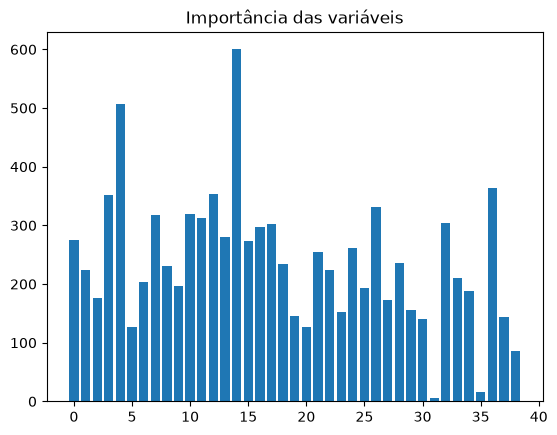

In [21]:
importancias_lgbm = lgbm.feature_importances_

logging.info("Plotando a importância das variáveis do modelo LightGBM...")
plt.bar(range(len(importancias_lgbm)), importancias_lgbm)
plt.title("Importância das variáveis")
plt.show()



### 11. Explicabilidade

c:\Users\vitor\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


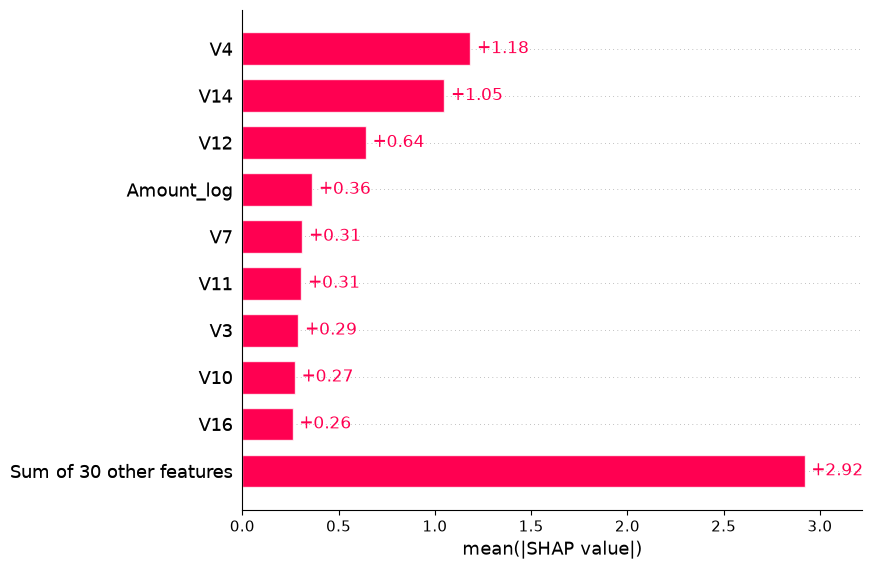

In [22]:
import shap

explainer = shap.TreeExplainer(lgbm)
shap_values = explainer(x_test[:80])

shap.plots.bar(shap_values)